# Modeling Training Intensity Prediction (kcal/min)

This notebook covers the predictive modeling stage on the `df_model` dataset prepared in Notebook 01. The data has already been cleaned and processed, so the analysis focuses exclusively on building and evaluating regression models.

The scope of work includes:
- splitting the data into training and test sets,
- building a naive baseline model (DummyRegressor), a reference model (Linear Regression), and a target model (Random Forest Regressor with hyperparameter tuning),
- evaluating model quality using cross-validation and an independent test set,
- feature importance analysis,
- error analysis,
- saving the trained model,
- a brief usage description and conclusions.

# Library Imports and Environment Configuration

In the first step, the libraries necessary for data processing, building regression models, and their evaluation were imported.

Additionally, data display parameters and plot style were configured to maintain visual consistency with Notebook 01 and facilitate interpretation of results.

A fixed `RANDOM_STATE = 42` was also set to ensure reproducibility of results.

In [1]:
# Base libraries
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Sklearn – models, pipelines, preprocessing, validation, metrics
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

# Visualization and display settings
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

# Rendering Markdown in notebook via Code
from IPython.display import Markdown, display

# Reproducibility 
import random 
RANDOM_STATE = 42 
np.random.seed(RANDOM_STATE) 
random.seed(RANDOM_STATE)

# Loading the Prepared Dataset

The final dataset `activities_model_ready.parquet`, prepared in *Notebook 01*, was loaded.

The dataset contains numerical and categorical features with unambiguous semantic interpretation and requires no additional cleaning beyond the transformations performed within the model pipelines.

In [2]:
# Loading the prepared dataset
df = pd.read_parquet('../data/processed/activities_model_ready.parquet')

# Basic dataset characteristics
N, M = df.shape
display(Markdown(
    f"The dataset contains **{N} observations** and **{M} variables** and was created "
    "from raw data containing **1340 observations** and **34 variables**, "
    "exported from the Garmin Connect platform."
))

# Preview of the first observations
df.head()

The dataset contains **1270 observations** and **13 variables** and was created from raw data containing **1340 observations** and **34 variables**, exported from the Garmin Connect platform.

,Activity Type,Distance,Avg HR,Max HR,Steps,Total Reps,Total Poses,Stress Change,Avg Stress,day_of_week,hour_sin,hour_cos,calories_per_min
0,Yoga,NaN,92,136,NaN,NaN,NaN,-18.0,74.0,5,-9.659258e-01,0.258819,3.996920
1,Cardio,NaN,145,179,NaN,NaN,NaN,NaN,NaN,4,-8.660254e-01,-0.500000,10.354052
2,Cardio,NaN,148,196,NaN,NaN,NaN,NaN,NaN,3,-9.659258e-01,0.258819,11.142658
3,Strength Training,NaN,89,113,NaN,5.0,1.0,NaN,NaN,2,-8.660254e-01,0.500000,3.863574
4,Yoga,NaN,102,119,NaN,NaN,NaN,90.0,88.0,2,1.224647e-16,-1.000000,5.198330


# Sanity Checks – Dataset Consistency Verification Before Modeling

Prior to building the models, a basic consistency verification of the dataset was performed. The presence of the target variable `calories_per_min`, the completeness of its values, and the conformity of data types with the assumptions made in *Notebook 01* were checked.

The target variable was kept in its original scale (`kcal/min`), ensuring direct interpretability of the results.

In [3]:
# Checking for the presence of the target variable
if 'calories_per_min' in df.columns:
    display(Markdown("Target variable `calories_per_min` is present in the dataset."))
else:
    display(Markdown("Target variable `calories_per_min` is missing from the dataset."))
    
# Checking completeness of the target variable
missing_target = df['calories_per_min'].isna().sum()
display(Markdown(f"Number of missing values in the target variable: {missing_target}"))

# Descriptive statistics of the target variable
display(Markdown("##### Descriptive statistics of the target variable"))
display(df['calories_per_min'].describe())

# Data type structure
display(Markdown("##### Data type structure of the dataset"))
display(df.dtypes.value_counts())

Target variable `calories_per_min` is present in the dataset.

Number of missing values in the target variable: 0

##### Descriptive statistics of the target variable

count    1270.000000
mean        6.109272
std         2.817879
min         0.093216
25%         4.225688
50%         5.148475
75%         6.694066
max        14.646244
Name: calories_per_min, dtype: float64

##### Data type structure of the dataset

float64    9
int64      2
str        1
int32      1
Name: count, dtype: int64

# Definition of the Target Variable and Input Features

The **target variable** of the model is training intensity expressed as the number of calories burned per minute (`calories_per_min`), calculated in *Notebook 01*.

The **input features** consist of the remaining columns in the dataset.

In [4]:
TARGET = 'calories_per_min'

# Splitting into input features (X) and target variable (y)
X = df.drop(columns=TARGET).copy()
y = df[TARGET].copy()

print(f"Number of observations: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

X.head()

Number of observations: 1270
Number of features: 12


,Activity Type,Distance,Avg HR,Max HR,Steps,Total Reps,Total Poses,Stress Change,Avg Stress,day_of_week,hour_sin,hour_cos
0,Yoga,NaN,92,136,NaN,NaN,NaN,-18.0,74.0,5,-9.659258e-01,0.258819
1,Cardio,NaN,145,179,NaN,NaN,NaN,NaN,NaN,4,-8.660254e-01,-0.500000
2,Cardio,NaN,148,196,NaN,NaN,NaN,NaN,NaN,3,-9.659258e-01,0.258819
3,Strength Training,NaN,89,113,NaN,5.0,1.0,NaN,NaN,2,-8.660254e-01,0.500000
4,Yoga,NaN,102,119,NaN,NaN,NaN,90.0,88.0,2,1.224647e-16,-1.000000


# Splitting Features into Numerical and Categorical

In order to apply appropriate transformations within the model pipelines, the input features were split into **categorical** and **numerical**.

In [5]:
categorical_features = ['Activity Type']

numeric_features = [
    col for col in X.columns
    if col not in categorical_features
]
print('Categorical feature:', categorical_features)
print('Numerical features:', numeric_features)

Categorical feature: ['Activity Type']
Numerical features: ['Distance', 'Avg HR', 'Max HR', 'Steps', 'Total Reps', 'Total Poses', 'Stress Change', 'Avg Stress', 'day_of_week', 'hour_sin', 'hour_cos']


# Preprocessing for Tree-Based Model

To prepare the data for training tree-based models, a `Pipeline` and `ColumnTransformer` were applied, ensuring that transformations are fitted exclusively on the training set and eliminating the risk of data leakage.

Applied transformations:
- **numerical features:** median imputation,
- **categorical feature:** imputation with a constant value `missing` + one-hot encoding.

In [6]:
# Numerical transformer: median imputation
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical transformer: constant value imputation + one-hot encoding
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Preprocessor for tree-based model
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numeric_features),
        ('cat', cat_transformer, categorical_features)
    ],
    remainder='drop'
)

# Preprocessing for Linear Regression (with Scaling)

In linear regression, median imputation and standardization (`StandardScaler`) were applied to **numerical features** — linear models are sensitive to the scale of variables, so standardization stabilizes the optimization process and facilitates interpretation of coefficients.

The **categorical feature** is processed identically to the tree-based model (imputation with a constant value `missing` + one-hot encoding).

In [7]:
# Numerical transformer for linear regression: median imputation + scaling
num_transformer_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessor for linear regression
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', num_transformer_lr, numeric_features),
        ('cat', cat_transformer, categorical_features)
    ],
    remainder='drop'
)

# Splitting Data into Training and Test Sets

The data was split into a **training set (80%)** and a **test set (20%)**.

**Stratification by the `Activity Type` variable** was applied to preserve the same proportions of activity types in both sets.

In [8]:
stratify_col = X['Activity Type']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=stratify_col
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (1016, 12)
Test shape: (254, 12)


# Baseline Model: DummyRegressor (Naive Baseline)

As a reference point, a `DummyRegressor` baseline model with the `median` strategy was used, which predicts a constant value equal to the median of the target variable `calories_per_min` in the training set.

This model does not learn any relationships between features and the target variable and serves exclusively as a **baseline**, representing the lower bound of quality that models learning the structure of the data should surpass.

In [9]:
# Baseline pipeline
dummy_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('model', DummyRegressor(strategy='median'))
])

dummy_pipeline.fit(X_train, y_train)
y_pred_dummy = dummy_pipeline.predict(X_test)

mae_dummy = mean_absolute_error(y_test, y_pred_dummy)
r2_dummy = r2_score(y_test, y_pred_dummy)

print(f"DummyRegressor – MAE (test): {mae_dummy:.4f}")
print(f"DummyRegressor – R²  (test): {r2_dummy:.4f}")

DummyRegressor – MAE (test): 1.8859
DummyRegressor – R²  (test): -0.1102


### Baseline Model Conclusions (DummyRegressor)

The baseline model achieves **MAE ≈ 1.89 kcal/min** and **R² < 0**, meaning its predictions are worse than predicting the mean value of the target variable.

# Reference Model: Linear Regression

Linear regression serves as the reference model that learns the relationships between features and training intensity. Due to the sensitivity of linear models to variable scale, standardization of numerical features was applied in the pipeline.

The model was evaluated using **MAE** and **R²** metrics on the test set and with 5-fold cross-validation. This allows for assessing both prediction accuracy and model stability.

In [10]:
# Pipeline: preprocessing + linear regression
lr_pipeline = Pipeline([
    ('preproc', preprocessor_lr),
    ('model', LinearRegression())
])

# Model training
lr_pipeline.fit(X_train, y_train)

# Prediction on the test set
y_pred_lr = lr_pipeline.predict(X_test)

# Test set metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression – MAE:  {mae_lr:.4f}")
print(f"Linear Regression – R²:  {r2_lr:.4f}")

# Cross-validation (5-fold)
scoring = {
    'neg_mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

cv_res_lr = cross_validate(
    lr_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

cv_mae_lr = -cv_res_lr['test_neg_mae']
cv_r2_lr = cv_res_lr['test_r2']

print(f"LR CV MAE  mean ± std:  {cv_mae_lr.mean():.4f} ± {cv_mae_lr.std():.4f}")
print(f"LR CV R²   mean ± std:  {cv_r2_lr.mean():.4f} ± {cv_r2_lr.std():.4f}")

Linear Regression – MAE:  0.4674
Linear Regression – R²:  0.9050
LR CV MAE  mean ± std:  0.4151 ± 0.0464
LR CV R²   mean ± std:  0.9477 ± 0.0163


### Reference Model Results Summary (Linear Regression)

The model achieved **MAE ≈ 0.47 kcal/min** and **R² ≈ 0.91** on the test set, representing a significant improvement over the baseline model.

Cross-validation (5-fold) confirms the stability of the results (**MAE ≈ 0.42 ± 0.05**, **R² ≈ 0.95 ± 0.02**).

Linear regression provides a solid reference point for the tree-based model.

# Target Model: Random Forest Regressor

Random Forest was chosen as the target model due to its ability to model non-linear relationships between features and the `calories_per_min` variable. Unlike linear regression, it:
- does not require variable scaling,
- is robust to outliers,
- effectively models feature interactions.

The model was evaluated using **MAE** and **R²** metrics on the test set and with 5-fold cross-validation. This allows for assessing both prediction accuracy and model stability.

In [11]:
# Pipeline: preprocessing + Random Forest
rf_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Model training
rf_pipeline.fit(X_train, y_train)

# Prediction on the test set
y_pred_rf = rf_pipeline.predict(X_test)

# Test set metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest – MAE:  {mae_rf:.4f}")
print(f"Random Forest – R²:  {r2_rf:.4f}")

# Cross-validation (5-fold) – MAE, R²
scoring = {
    'neg_mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

cv_res_rf = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

cv_mae_rf = -cv_res_rf['test_neg_mae']
cv_r2_rf = cv_res_rf['test_r2']

print(f"RF CV MAE  mean ± std:  {cv_mae_rf.mean():.4f} ± {cv_mae_rf.std():.4f}")
print(f"RF CV R²   mean ± std:  {cv_r2_rf.mean():.4f} ± {cv_r2_rf.std():.4f}")

Random Forest – MAE:  0.4327
Random Forest – R²:  0.9265
RF CV MAE  mean ± std:  0.4004 ± 0.0383
RF CV R²   mean ± std:  0.9464 ± 0.0149


## Target Model Results Summary (Random Forest)

The model achieved **MAE ≈ 0.43 kcal/min** and **R² ≈ 0.93** on the test set, representing a significant improvement over the reference model, indicating the presence of non-linear relationships in the data.

Cross-validation (5-fold) confirms the stability of the results (**MAE ≈ 0.40 ± 0.04**, **R² ≈ 0.95 ± 0.02**). 

Random Forest is the best-performing model among the analyzed approaches.

## Random Forest Hyperparameter Tuning (RandomizedSearchCV)

To verify the model, hyperparameter tuning was performed using `RandomizedSearchCV` (5-fold CV). Random search over the parameter space was applied, allowing for efficient identification of good configurations at a moderate computational cost.

In [12]:
# Pipeline for tuning
rf_pipeline_tuning = Pipeline([
    ('preproc', preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

# Hyperparameter space
param_dist = {
    'model__n_estimators': [200, 300, 400, 500],
    'model__max_depth': [None, 5, 10, 20, 30],
    'model__max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

# RandomizedSearchCV
rs = RandomizedSearchCV(
    estimator=rf_pipeline_tuning,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

rs.fit(X_train, y_train)

print('Best parameters:', rs.best_params_)

# Best model
best_rf = rs.best_estimator_

# Evaluation on the test set
y_pred_best = best_rf.predict(X_test)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Best RF – MAE (test):  {mae_best:.4f}")
print(f"Best RF – R²  (test):  {r2_best:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 0.7, 'model__max_depth': None}
Best RF – MAE (test):  0.4288
Best RF – R²  (test):  0.9182


### Random Forest Hyperparameter Tuning Summary

Best configuration:
- **n_estimators = 200**
- **max_depth = None**
- **max_features = 0.7**
- **min_samples_split = 2**
- **min_samples_leaf = 4**

Evaluation on the test set:
- **MAE (test) ≈ 0.4288 kcal/min**
- **R² (test) ≈ 0.9182**

Tuning did not yield a clear improvement over the baseline RF model, indicating that the default model configuration was already close to the optimum within the considered hyperparameter space. The baseline Random Forest version was adopted as the target model for the project.

# Model Quality Comparison – DummyRegressor, Linear Regression, and Random Forest

Three models were compared:
- **DummyRegressor** – baseline (naive) model,
- **Linear Regression** – reference model,
- **Random Forest** – target model.

Evaluation was based on:
- **MAE** – `kcal/min`,
- **R²** – proportion of explained variance,
- 5-fold CV for learning models (Linear Regression and Random Forest).

In [13]:
results = pd.DataFrame({
    'model': ['DummyRegressor', 'LinearRegression', 'RandomForest'],
    'mae_test': [mae_dummy, mae_lr, mae_rf],
    'r2_test': [r2_dummy, r2_lr, r2_rf],
    'cv_mae_mean': [None, cv_mae_lr.mean(), cv_mae_rf.mean()],
    'cv_mae_std': [None, cv_mae_lr.std(), cv_mae_rf.std()],
    'cv_r2_mean': [None, cv_r2_lr.mean(), cv_r2_rf.mean()],
    'cv_r2_std': [None, cv_r2_lr.std(), cv_r2_rf.std()]
})

print('Model quality comparison:')
results

Model quality comparison:


,model,mae_test,r2_test,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std
0,DummyRegressor,1.885874,-0.110248,NaN,NaN,NaN,NaN
1,LinearRegression,0.467377,0.905004,0.415093,0.046379,0.947674,0.016255
2,RandomForest,0.432706,0.926483,0.400391,0.038254,0.946359,0.014917


### Model Quality Comparison

| Aspect | DummyRegressor | Linear Regression | Random Forest |
|--------|----------------|-------------------|---------------|
| **MAE (test)** | ~1.89 | ~0.47 | **~0.43** |
| **R² (test)** | < 0 | ~0.91 | **~0.93** |
| **CV MAE** | – | ~0.42 ± 0.05 | **~0.40 ± 0.04** |
| **CV R²** | – | ~0.95 ± 0.02 | **~0.95 ± 0.01** |
| **Relationships** | none | linear | **non-linear, complex** |
| **Scaling requirements** | none | requires scaling | none |
| **Role in project** | naive baseline | reference model | **target model** |

### Visual Model Quality Comparison

The chart below presents a comparison of MAE values on the test set for the three models: DummyRegressor, Linear Regression, and Random Forest.

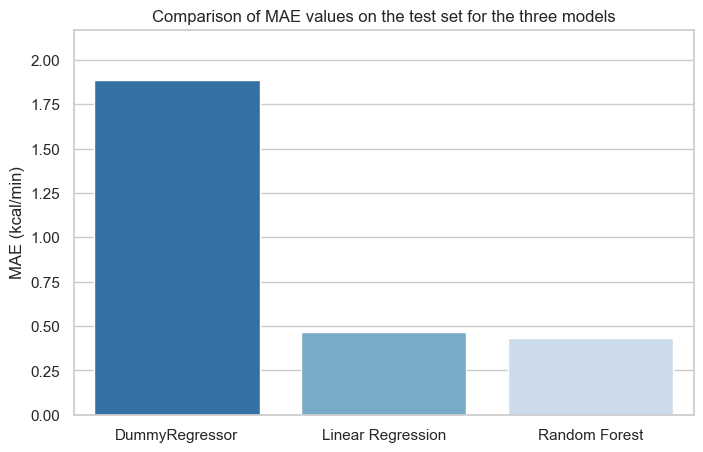

In [14]:
models = ['DummyRegressor', 'Linear Regression', 'Random Forest']
mae_values = [mae_dummy, mae_lr, mae_rf]

plt.figure(figsize=(8, 5)) 
sns.barplot( 
    x=models, 
    y=mae_values, 
    hue=models,
    palette='Blues_r', 
    legend=False
)

plt.title('Comparison of MAE values on the test set for the three models')
plt.ylabel('MAE (kcal/min)')
plt.ylim(0, max(mae_values) * 1.15)

plt.show()

### Model Comparison Conclusions

- The baseline confirms the existence of structure in the data.
- Linear regression provides a significant improvement and stable results.
- Random Forest achieves the best quality by modeling non-linearities.

**Random Forest** remains the target model due to its highest accuracy and stability.

# Predictive Model Feature Interpretation

Following the selection of the target model (**Random Forest**), a feature importance analysis was conducted in order to:
- identify the key predictors of `calories_per_min`,
- assess the consistency of results,
- increase the transparency and interpretability of the model.

Two approaches were applied in the analysis:
1. **Built-in importance** (impurity-based feature importance).
2. **Permutation importance** on the test set.

Both approaches provide different perspectives and complement each other.

## Technical Aspect of Feature Interpretation in the Pipeline

The model operates within a pipeline, therefore:
- built-in importance refers to **features after transformation**,
- categorical variables are split into multiple binary columns,
- permutation importance refers to **original input columns**.

### Feature Name Extraction After Preprocessing

In [15]:
# Accessing the trained Random Forest model from the pipeline
rf_model = rf_pipeline.named_steps['model']

# Numerical features
feature_names_num = numeric_features

# Categorical features
feature_names_cat = (
    rf_pipeline
    .named_steps['preproc']
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_features)
)

# Combined feature list
feature_names = np.concatenate([feature_names_num, feature_names_cat])
feature_names

array(['Distance', 'Avg HR', 'Max HR', 'Steps', 'Total Reps',
       'Total Poses', 'Stress Change', 'Avg Stress', 'day_of_week',
       'hour_sin', 'hour_cos', 'Activity Type_Cardio',
       'Activity Type_Strength Training', 'Activity Type_Walking',
       'Activity Type_Yoga'], dtype=object)

## Feature Interpretation Methods

### Random Forest Built-in Feature Importance

Importance is based on the total reduction in impurity across trees.

Features with the highest values *participate most frequently in splits* and *reduce error the most*.

Limitation: the method may favor features with a greater number of possible splits (e.g., after one-hot encoding).

In [16]:
# Retrieving feature importances
importances = rf_model.feature_importances_

# DataFrame with results
df_fi = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

df_fi.head(15)

,feature,importance
1,Avg HR,0.960227
2,Max HR,0.010872
8,day_of_week,0.005783
9,hour_sin,0.004909
10,hour_cos,0.004102
11,Activity Type_Cardio,0.002709
7,Avg Stress,0.002247
0,Distance,0.002200
13,Activity Type_Walking,0.001818
6,Stress Change,0.001591


### Permutation Importance

The method involves shuffling a single feature and measuring the resulting drop in quality (here: increase in MAE).

Advantages:
- evaluation on the test set (generalization),
- independence from the model structure,
- interpretation at the level of original features,
- greater robustness to one-hot encoding artifacts.

In [17]:
perm = permutation_importance(
    rf_pipeline,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring='neg_mean_absolute_error'
)

perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

perm_df.head(15)

,feature,importance_mean,importance_std
2,Avg HR,2.276691,0.101397
0,Activity Type,0.098685,0.021084
3,Max HR,0.022597,0.006923
10,hour_sin,0.011213,0.006739
1,Distance,0.008660,0.002813
11,hour_cos,0.007962,0.004178
4,Steps,0.005511,0.001523
5,Total Reps,0.001796,0.000671
8,Avg Stress,0.001125,0.002027
6,Total Poses,0.000753,0.000774


## Feature Importance Analysis Conclusions

- `Avg HR` is by far the most important predictor of training intensity.
- The results of both methods are consistent, which increases the credibility of the interpretation.
- The remaining features play a supporting role and contribute significantly less.

The dominance of `Avg HR` is consistent with the physiological interpretation of exercise intensity.

# Predictive Model Error Analysis

The goal is to assess **for which observations the model makes errors** and whether they have a systematic character.

The analysis allows for:
- evaluating the agreement between predictions and actual values,
- examining the distribution of residuals and their dependence on the intensity level,
- checking whether the model makes larger errors for specific activity types.

In [18]:
# Random Forest model predictions on the test set
y_pred = rf_pipeline.predict(X_test)

# DataFrame for error analysis
df_errors = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred,
    'residual': y_test - y_pred,
    'Activity Type': X_test['Activity Type'].values
})

print(df_errors.head())

        y_true     y_pred  residual Activity Type
753   3.892562   3.742844  0.149718          Yoga
364  10.419907  10.181894  0.238013        Cardio
756   5.723370   5.584299  0.139071          Yoga
652   4.718101   4.712927  0.005174          Yoga
452   6.158631   6.596151 -0.437520          Yoga


## Predictions vs. Actual Values

The `y_true vs y_pred` plot allows for assessing the model fit.

Points clustered around the 45° line indicate good prediction quality.

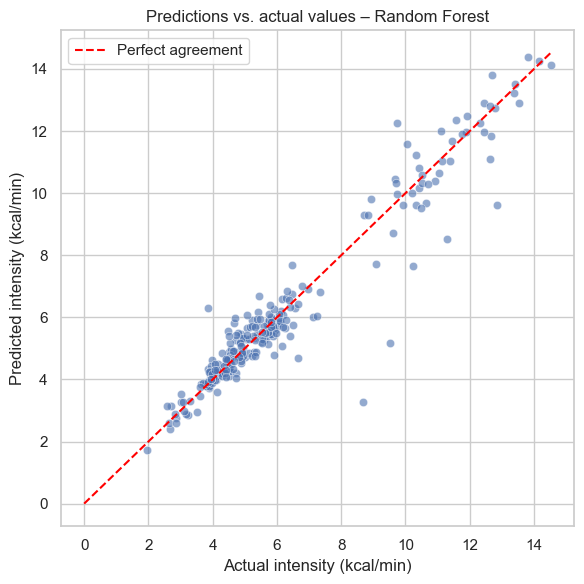

In [20]:
plt.figure(figsize=(6, 6))
sns.scatterplot(
    x=df_errors['y_true'],
    y=df_errors['y_pred'],
    alpha=0.6
)
plt.plot(
    [0, df_errors['y_true'].max()],
    [0, df_errors['y_true'].max()],
    color='red',
    linestyle='--',
    label='Perfect agreement'
)
plt.xlabel('Actual intensity (kcal/min)')
plt.ylabel('Predicted intensity (kcal/min)')
plt.title('Predictions vs. actual values – Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

## Residual Analysis

In an ideal scenario, residuals should be:
- randomly scattered around 0,
- free of trend relative to `y_pred`,
- free of a "funnel" effect (heteroscedasticity).

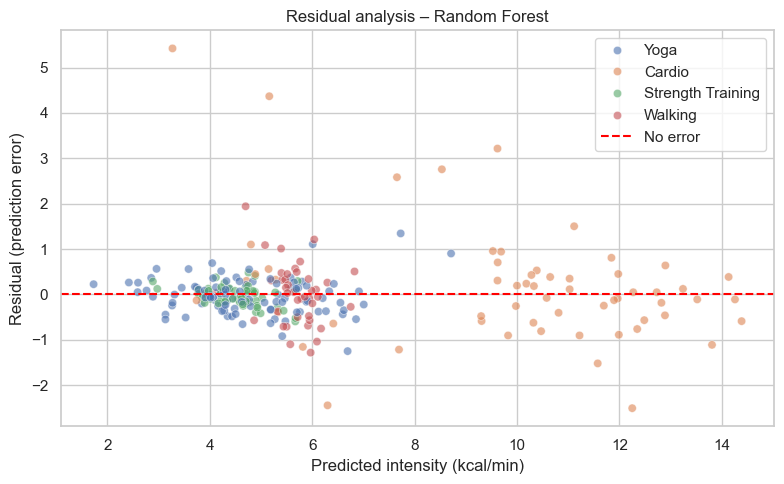

In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot( 
    data=df_errors, 
    x='y_pred', 
    y='residual', 
    hue='Activity Type', 
    alpha=0.6 
)
plt.axhline(0, color='red', linestyle='--', label='No error')
plt.xlabel('Predicted intensity (kcal/min)')
plt.ylabel('Residual (prediction error)')
plt.title('Residual analysis – Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

## Errors per Activity Type

Residual statistics were analyzed by `Activity Type` to check whether the model differs in prediction quality across training types.

The mean, median, and standard deviation of errors were compared for each category.

In [23]:
errors_by_activity = df_errors.groupby('Activity Type')['residual'].agg(['mean', 'std', 'median', 'count'])
errors_by_activity

,mean,std,median,count
Activity Type,,,,
Cardio,0.172500,1.347584,0.048860,59
Strength Training,-0.037654,0.223395,-0.062193,54
Walking,0.026342,0.655069,0.032553,41
Yoga,-0.031197,0.388020,-0.047871,100


## Error Analysis Conclusions

- Predictions are close to actual values (agreement with the ideal line).
- Residuals are scattered around zero — no systematic overestimation or underestimation.
- No clear systematic trend is observed as a function of intensity level, although for high values (mainly `Cardio`) a larger spread of errors is visible.
- The model maintains comparable quality across different activity types, with greater variability in `Cardio`.
- Individual larger errors are incidental in nature and do not form a consistent pattern.

These results indicate that the model not only achieves high global quality (MAE, R²), but also **maintains stability at the level of individual observations**.

# Saving the Trained Model and Pipeline

The trained **pipeline (preprocessing + Random Forest)** was saved for reuse outside the notebook. Saving the entire structure guarantees transformation consistency and full replicability of predictions.

`joblib` was used for serialization.

In [24]:
# Path to the project root directory (notebook located in a subdirectory, e.g. notebooks/)
project_root = os.path.abspath('..')

# Models directory in the project root
models_dir = os.path.join(project_root, 'models')
os.makedirs(models_dir, exist_ok=True)

# Saving the pipeline
joblib.dump(rf_pipeline, os.path.join(models_dir, 'random_forest_pipeline.joblib'))

# Saving metadata
metadata = {
    'python_version': sys.version,
    'sklearn_version': __import__('sklearn').__version__,
    'model_type': 'RandomForestRegressor',
    'description': 'Pipeline: preprocessing + Random Forest for calories_per_min prediction'
}
joblib.dump(metadata, os.path.join(models_dir, 'model_metadata.joblib'))

print(f"Model and metadata saved in directory '{models_dir}'.")

Model and metadata saved in directory 'C:\Users\micha\PycharmProjects\training-intensity-prediction\models'.


## Reproducibility Notes

- The complete pipeline (preprocessing + model) was saved, eliminating the risk of inconsistent transformations upon reuse.
- Artifacts were placed in the `models/` directory, separating them from experimental code.
- Additionally, metadata (environment versions and model description) was saved, enabling reconstruction of the training conditions.

# Modeling and Deployment Summary of the Predictive Model

This notebook covered the complete predictive modeling process for training intensity (`calories_per_min`): from pipeline construction, through evaluation and interpretation, to saving the model for further use.

## Key Results
- **Linear Regression (reference model)**: MAE ≈ 0.46, R² ≈ 0.91 – confirms a strong predictive signal in the data.
- **Random Forest (target model)**: MAE ≈ 0.43, R² ≈ 0.93 – best prediction quality and stable results in cross-validation.
- **Feature interpretation**: Average heart rate (`Avg HR`) is the dominant predictor of intensity (remaining variables have only a supporting influence, which is consistent with physiological knowledge).
- **Error analysis**: No systematic deviations, residuals scattered around zero (greater variability for Cardio results from the nature of this activity, not from a structural model error).

The model demonstrates good generalization and shows no signs of overfitting.

## Model Deployment
The complete pipeline (preprocessing + model) was saved in the `models/` directory along with environment metadata. This ensures:
- transformation consistency during inference,
- the ability to use the model outside the notebook,
- experiment reproducibility.

On this basis, an **API (FastAPI)** was developed to enable predictions.

---

**Random Forest** is a stable and practical predictive model, ready for further integration with an analytical system.